In [1]:
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR
import pickle
import numpy as np
import keras
import robot_vlp.data.preprocessing as p
import matplotlib.pyplot as plt


from robot_vlp.config import MODELS_DIR
from robot_vlp.modeling.train_rnn import ang_loss_fn

import robot_vlp.data.preprocessing as p
import robot_vlp.data.path_generation as pg
import robot_vlp.modeling.model_performance_plotting as pp

%load_ext autoreload
%autoreload 2

2024-11-12 16:42:09.879 | INFO     | robot_vlp.config:<module>:11 - PROJ_ROOT path is: /Users/tyrelglass/PhD/Repositories/robot-vlp


In [2]:
# pull in processed dataset
with open(PROCESSED_DATA_DIR/'data.pickle', 'rb') as handle:
    data = pickle.load(handle)



x_win = data['X_valid']
y_win = data['y_valid']

In [3]:
win_no = 46

def plot_pre(win_no):
    x = x_win[win_no]
    # plt.plot(y_win[:20,0]/7, y_win[:20,1]/7, marker = '.', alpha = 0.5)
    plt.plot(x[:,0],x[:,1], label = 'encoder', marker = '.', alpha = 0.4,linestyle = '--')
    arrow_len = 0.005
    headings = (x[:,2]*360 - 180)/180*np.pi
    dx = np.sin( headings)* arrow_len
    dy = np.cos(headings)* arrow_len

    for i in range(len(x)):
        plt.arrow(x[i,0], x[i,1], dx[i], dy[i], alpha = 0.9, head_width = 0.00, width = 0.00001, color = 'k')


    heading = y_win[win_no,2] /180*np.pi
    ydx = np.sin(heading)* arrow_len
    ydy = np.cos( heading)* arrow_len

    plt.plot(y_win[win_no,0]/7, y_win[win_no,1]/7, marker = '.', c = 'r')
    plt.arrow(y_win[win_no,0]/7, y_win[win_no,1]/7, ydx, ydy, head_width =0.00, width = 0.00001, color = 'r')



    pre = model.predict(x_win[win_no:win_no+1])
    pre_x = pre[0][0,0]/7
    pre_y = pre[0][0,1]/7
    pre_ang = p.vector_to_ang(pre[1], unit = 'degrees').numpy()[0] / 180 * np.pi
    ydx = np.sin(pre_ang)* arrow_len
    ydy = np.cos( pre_ang)* arrow_len
    plt.plot(pre_x, pre_y, c = 'g', marker = '.')
    plt.arrow(pre_x, pre_y, ydx, ydy, head_width =0.00, width = 0.00001, color = 'g')



# plt.xlim(0.55,0.72)
# plt.ylim(0.625,0.655)



NameError: name 'model' is not defined

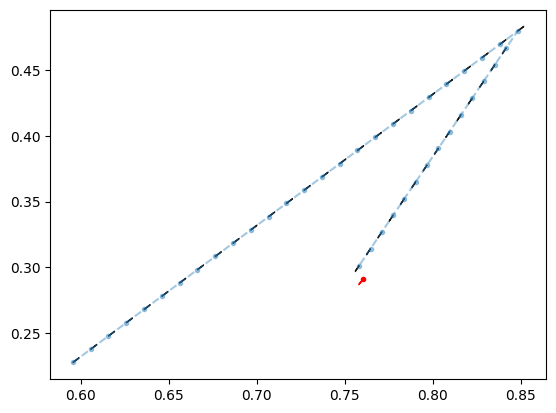

In [4]:
plot_pre(15)


12363/12363 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step
moddel err:  0.14606866145264855
odo err:  0.7058381045475738
vlp err:  0.2675820974325861


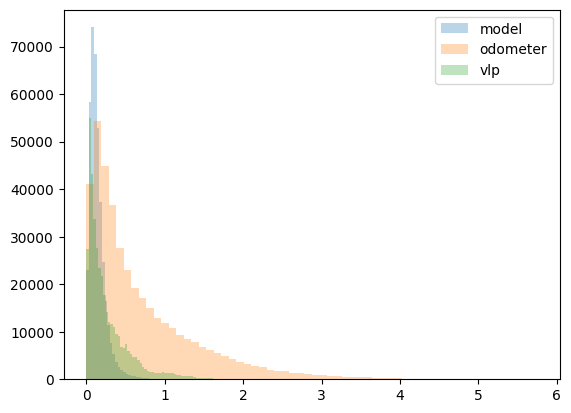

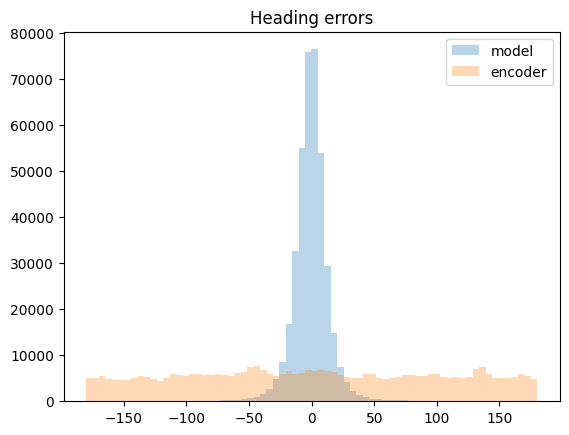

In [65]:
model = pp.load_model(model_name = 'model_02.keras')
x_win = data['X_train']
y_win = data['y_train']
all_pre = model.predict(x_win)


dist_errs = np.sqrt(np.square(all_pre[0][:,0] - y_win[:,0]) + np.square(all_pre[0][:,1] - y_win[:,1]))
print('moddel err: ',dist_errs.mean())
_ = plt.hist(dist_errs, bins = 60, alpha = 0.3, label = 'model')

odo_errs = np.sqrt(np.square(x_win[:,-1,0]*7 - y_win[:,0]) + np.square(x_win[:,-1,1]*7 - y_win[:,1]))
print('odo err: ',odo_errs.mean())
_ = plt.hist(odo_errs, bins = 60, alpha = 0.3, label = 'odometer')

vlp_errs = np.sqrt(np.square(x_win[:,-1,3]*7 - y_win[:,0]) + np.square(x_win[:,-1,4]*7 - y_win[:,1]))
print('vlp err: ',vlp_errs.mean())
_ = plt.hist(vlp_errs, bins = 60, alpha = 0.3, label = 'vlp')

plt.legend()

plt.figure()
plt.title('Heading errors')
ang_pre = p.vector_to_ang(all_pre[1], unit = 'degrees').numpy()
ang_pre_mag = np.linalg.norm(all_pre[1], axis = 1)
ang_real = y_win[:,2]
ang_err = pp.min_ang_diff(ang_pre, ang_real)
_ = plt.hist(ang_err, bins = 70, alpha = 0.3, label = 'model')

ang_enc = x_win[:,-1,2]
ang_enc_err = pp.min_ang_diff(ang_enc, ang_real)
_ = plt.hist(ang_enc_err, bins = 70, alpha = 0.3, label = 'encoder')
plt.legend()

12363/12363 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
moddel err:  0.12458062037643629
odo err:  0.7058381045475738
vlp err:  0.2675820974325861


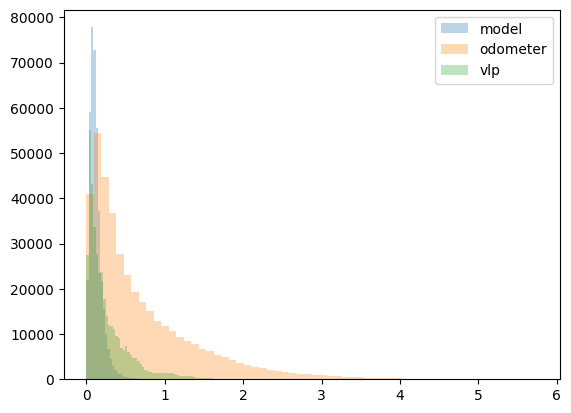

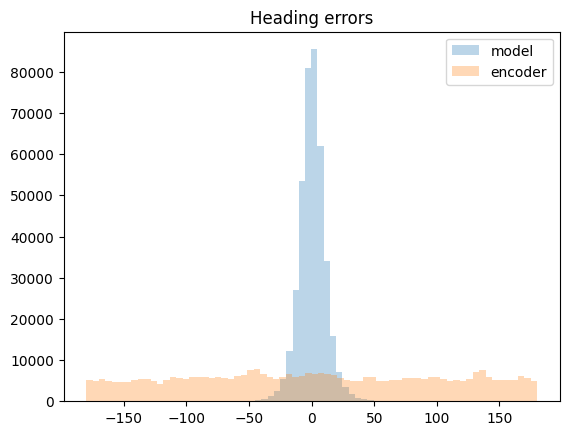

In [66]:
model = pp.load_model(model_name = 'model_03.keras')
x_win = data['X_train']
y_win = data['y_train']
all_pre = model.predict(x_win)


dist_errs = np.sqrt(np.square(all_pre[0][:,0] - y_win[:,0]) + np.square(all_pre[0][:,1] - y_win[:,1]))
print('moddel err: ',dist_errs.mean())
_ = plt.hist(dist_errs, bins = 60, alpha = 0.3, label = 'model')

odo_errs = np.sqrt(np.square(x_win[:,-1,0]*7 - y_win[:,0]) + np.square(x_win[:,-1,1]*7 - y_win[:,1]))
print('odo err: ',odo_errs.mean())
_ = plt.hist(odo_errs, bins = 60, alpha = 0.3, label = 'odometer')

vlp_errs = np.sqrt(np.square(x_win[:,-1,3]*7 - y_win[:,0]) + np.square(x_win[:,-1,4]*7 - y_win[:,1]))
print('vlp err: ',vlp_errs.mean())
_ = plt.hist(vlp_errs, bins = 60, alpha = 0.3, label = 'vlp')

plt.legend()

plt.figure()
plt.title('Heading errors')
ang_pre = p.vector_to_ang(all_pre[1], unit = 'degrees').numpy()
ang_pre_mag = np.linalg.norm(all_pre[1], axis = 1)
ang_real = y_win[:,2]
ang_err = pp.min_ang_diff(ang_pre, ang_real)
_ = plt.hist(ang_err, bins = 70, alpha = 0.3, label = 'model')

ang_enc = x_win[:,-1,2]
ang_enc_err = pp.min_ang_diff(ang_enc, ang_real)
_ = plt.hist(ang_enc_err, bins = 70, alpha = 0.3, label = 'encoder')
plt.legend()

In [82]:
y_win.shape

(186731, 3)

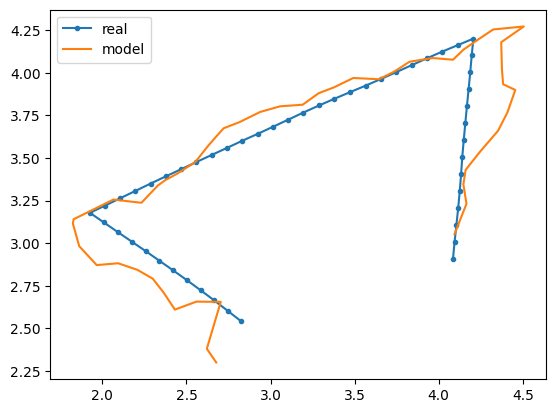

In [7]:
start = 0
end = start + 50

x_real = y_win[start:end, 0]
y_real = y_win[start:end,1]
x_pre = all_pre[0][start:end, 0]
y_pre = all_pre[0][start:end, 1]

plt.plot(x_real, y_real, label = 'real', marker = '.')
plt.plot(x_pre, y_pre, label = 'model')

# err2 = pp.min_ang_diff(pre[1:], real[:-1])
# plt.plot(err2, label = '2', alpha = 0.4)

# err3 = pp.min_ang_diff(pre[:-1], real[1:])
# plt.plot(err3, label = '3', alpha = 0.4)

plt.legend()

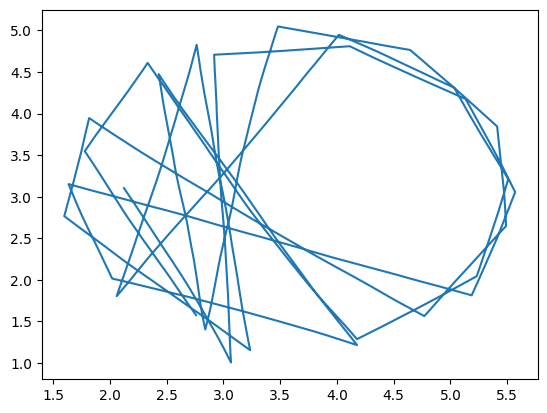

In [10]:
plot_params = {
    'model_name':'model_02.keras',
    'name':'pre_model_ex3',
    'start_index':0,
    'path_length':50,
    'filter_params':{
        'n':'n_10',
        'direction':'shuffle',
        'vlp_acc':'med_acc', 
        'odo_acc':'err_1', 
        'run':'run2'
    }
}  
win_len = 40
X_data_all_runs, y_data_all_runs = pp.load_run_data(plot_params['filter_params'])  # pull target runs
X_data = X_data_all_runs[0] # take first matching run
y_data = y_data_all_runs[0]
# X_all = window_every_sample(X_data, win_len = win_len) # create windows with stride 1
# X_all_scaled = p.apply_scaler(X_all, p.build_scaler())
# model = load_model(model_name= plot_params['model_name'])
# pre = model.predict(X_all_scaled)

X_train_window, y_train = p.create_windows([X_data], [y_data], overlap = 0.9, window_len = 10)

plt.plot(y_train[:,0], y_train[:,1])

In [22]:
plot_params = {
    'model_name':'model_02.keras',
    'name':'pre_model_ex3',
    'start_index':0,
    'path_length':500,
    'filter_params':{
        # 'n':'n_4',
        # 'direction':'_clock',
        # 'vlp_acc':'high_acc', 
        # 'odo_acc':'err_1', 
        # 'run':'run2',
        'rad':'rad_1.5_'
    }
}

pp.plot_model_predictions(plot_params)

IndexError: list index out of range

In [55]:
plot_params = {
    'model_name':'model_02.keras',
    'name':'pre_model_ex3',
    'start_index':0,
    'path_length':500,
    'filter_params':{
        # 'n':'n_4',
        # 'direction':'_clock',
        # 'vlp_acc':'high_acc', 
        # 'odo_acc':'err_1', 
        # 'run':'run2',
        'rad':'rad_1.5_'
    }
}


In [56]:
data_dir = INTERIM_DATA_DIR / 'path_data'
file_list = [file_name for file_name in data_dir.iterdir() if file_name.stem[0] != "."]


In [58]:
par_list = list(plot_params['filter_params'].values())
mode = 'include'
par_list

['rad_1.5_']

In [59]:
tar_list = file_list
for par in par_list:
    if mode == 'include':
        tar_list = [e for e in tar_list if (par in str(e.stem))]
    elif mode == 'exclude':
        tar_list = [e for e in tar_list if (par not in str(e.stem))]
tar_list

[]

In [64]:
'1.5'.replace('.','-')

'1-5'

In [60]:
tar_list = file_list
par_list

['rad_1.5_']

In [61]:
par

'rad_1.5_'

In [53]:
# [e for e in tar_list]

In [51]:
[e for e in tar_list if (par in str(e.stem))]

[]

In [47]:
'rad_1.5' not in 'anticlockwise_rad_1.5_run2'

False

In [63]:
file_list[2].stem

'n_6_high_acc_err_3_shuffle_rad_2'